# 2.1 — Le workflow d'apprentissage automatique

**Navigation** : [<< 01-PythonForDataScience](../01-PythonForDataScience/) | [2.2-Descente-de-gradient >>](2.2-Descente-de-gradient.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Ce notebook enseigne le **workflow fondamental** de l'apprentissage automatique supervisé : séparer les données (train/test), ajuster un modèle (`fit`), prédire (`predict`), puis évaluer. Il répond à une question centrale : pourquoi évalue-t-on sur des données que le modèle n'a **pas** vues ? Il montre aussi comment rendre le **surapprentissage** (overfitting) directement visible. C'est le prérequis de `2.2-Descente-de-gradient` et de toute la série `02-ML-Cours`.

### Objectifs d'apprentissage

1. Comprendre POURQUOI on sépare un jeu de données en entraînement et test.
2. Exécuter le workflow `fit` / `predict` / `evaluate` avec scikit-learn.
3. Rendre le surapprentissage visible grâce à un balayage de complexité.
4. Distinguer les métriques de classification (accuracy) et de régression (MAE).

### Prérequis

- NumPy et Pandas (voir `01-PythonForDataScience`).
- Bases de Python (boucles, fonctions, indexation).

> **Référence.** Mitchell, T. (1997), *Machine Learning*, McGraw-Hill. La distinction entraînement/généralisation et le surapprentissage (overfitting) y sont définis comme le concept central de l'apprentissage supervisé.

In [1]:
# Configuration : imports et graine aléatoire
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("Configuration OK : 2.1 - Workflow ML")

Configuration OK : 2.1 - Workflow ML


## 1. Le jeu de données

Nous utilisons un jeu de données **synthétique** généré par `make_classification`. Le choix d'un jeu synthétique (plutôt qu'un CSV réel) est délibéré :

- il est **déterministe** (même `random_state` → mêmes données), donc reproductible ;
- on **contrôle** le niveau de bruit et le nombre de caractéristiques informatives, ce qui permet d'observer proprement le surapprentissage ;
- aucune dépendance à un chemin de fichier fragile.

Paramètres utilisés :

- `n_samples=500` — 500 observations.
- `n_features=8` — 8 caractéristiques au total.
- `n_informative=5` — 5 caractéristiques réellement porteuses d'information.
- `n_redundant=2` — 2 caractéristiques redondantes (combinaisons linéaires des informatives).
- `flip_y=0.10` — 10 % des étiquettes sont inversées (bruit de label).
- `random_state=42` — pour la reproductibilité.

Forme de X : (500, 8)
Forme de y : (500,)

Répartition des classes :
0    259
1    241
Name: count, dtype: int64


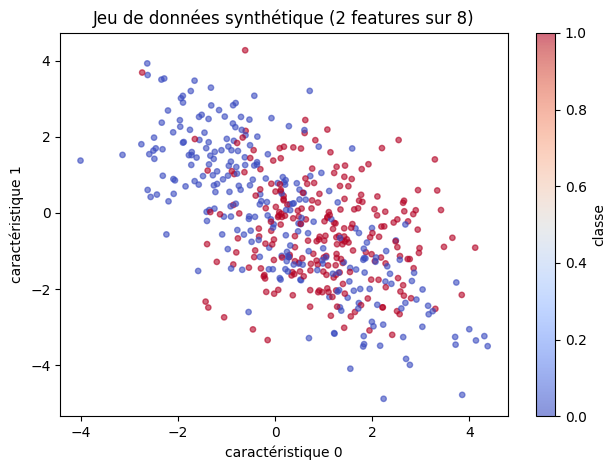

In [2]:
# Génération du jeu de données synthétique (exemple résolu)
X, y = make_classification(
    n_samples=500,
    n_features=8,
    n_informative=5,
    n_redundant=2,
    flip_y=0.10,
    random_state=42,
)

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("\nRépartition des classes :")
print(pd.Series(y).value_counts())

# Aperçu visuel : deux premières caractéristiques
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=15)
plt.colorbar(label='classe')
plt.xlabel('caractéristique 0')
plt.ylabel('caractéristique 1')
plt.title('Jeu de données synthétique (2 features sur 8)')
plt.tight_layout()
plt.show()

## 2. Pourquoi séparer train et test ?

Le concept-clé est le **principe du holdout** : on évalue un modèle sur des données qu'il n'a **pas** vues pendant l'entraînement. Pourquoi ? Parce qu'un modèle suffisamment flexible peut **mémoriser** les données d'entraînement (y compris leur bruit) sans pour autant *généraliser* à de nouvelles données. Mesurer la performance sur les données d'entraînement surestime donc la vraie capacité du modèle.

L'évaluation sur un ensemble de test distinct fournit une estimation **honnête** de la capacité de généralisation.

> **Référence.** Stone, M. (1974), *Cross-Validatory Choice and Assessment of Statistical Predictions*, Journal of the Royal Statistical Society. Series B (Methodological) 36(2):111-147. La validation croisée et le principe d'évaluation sur des données non vues fondent la mesure honnête de la capacité de généralisation.

In [3]:
# Exemple résolu : découpage stratifié train/test (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Taille entraînement :", X_train.shape, y_train.shape)
print("Taille test         :", X_test.shape, y_test.shape)
print()
# stratify=y conserve les proportions de classes entre train et test
print("Proportion classe 1 - train : {:.3f}".format((y_train == 1).mean()))
print("Proportion classe 1 - test  : {:.3f}".format((y_test == 1).mean()))

Taille entraînement : (350, 8) (350,)
Taille test         : (150, 8) (150,)

Proportion classe 1 - train : 0.483
Proportion classe 1 - test  : 0.480


### Exercice 1 : comparer un découpage naïf au découpage stratifié

**Contexte.** Le paramètre `stratify=y` garantit que les proportions de classes sont conservées entre `train` et `test`. Que se passe-t-il si l'on ignore cette précaution ?

**Objectif.** Implémentez un découpage **naïf** : prenez les 70 % premières lignes du jeu de données comme entraînement (sans mélanger, sans stratifier), puis comparez la proportion de classe 1 dans ce `train` naïf à celle du `train` stratifié ci-dessus.

**Indices.**

- *Étape 1* : calculer `n_train_naif = int(0.7 * len(X))`.
- *Étape 2* : extraire `X_train_naif = X[:n_train_naif]` et `y_train_naif = y[:n_train_naif]`.
- *Indice* : comparez `(y_train_naif == 1).mean()` à `(y_train == 1).mean()`.

La cellule de stub ci-dessous est à compléter.

In [4]:
# Exercice 1 : découpage naïf (70% premières lignes) vs stratifié
n_train_naif = int(0.7 * len(X))
# TODO etudiant : extraire X_train_naif, y_train_naif, X_test_naif, y_test_naif
X_train_naif = None  # TODO etudiant : remplacer
y_train_naif = None  # TODO etudiant : remplacer

# TODO etudiant : calculer la proportion de classe 1 dans le train naïf vs le train stratifié
prop_naif = None  # TODO etudiant : remplacer (proportion de classe 1 dans y_train_naif)
prop_stratifie = None  # TODO etudiant : remplacer (proportion de classe 1 dans y_train)

print(f"Exercice 1 a completer : prop classe 1 (naif) = {prop_naif}, (stratifie) = {prop_stratifie}")

Exercice 1 a completer : prop classe 1 (naif) = None, (stratifie) = None


## 4. Premier modèle : un arbre de décision

Un **arbre de décision** (`DecisionTreeClassifier`) classe une observation en posant une suite de questions binaires sur les caractéristiques (« la feature 3 est-elle > 0.5 ? »), ce qui partitionne l'espace en régions. Le paramètre clé est `max_depth` : il contrôle la **profondeur** maximale de l'arbre, donc sa **complexité**. Un arbre peu profond sous-apprend (trop rigide) ; un arbre très profond surapprend (il mémorise).

> **Référence.** Breiman, L., Friedman, J., Olshen, R. & Stone, C. (1984), *Classification and Regression Trees*, Wadsworth. Les arbres CART et la notion de profondeur (complexité du modèle) y sont introduits ; un arbre trop profond mémorise les données d'entraînement.

In [5]:
# Exemple résolu : arbre de décision de profondeur 3
arbre = DecisionTreeClassifier(max_depth=3, random_state=42)
arbre.fit(X_train, y_train)

# Prédictions sur train ET test pour comparer
y_pred_train = arbre.predict(X_train)
y_pred_test = arbre.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# L'accuracy de train est en général >= à celle de test : c'est attendu
print("Accuracy - train : {:.3f}".format(acc_train))
print("Accuracy - test  : {:.3f}".format(acc_test))

Accuracy - train : 0.874
Accuracy - test  : 0.773


## 5. Rendre le surapprentissage VISIBLE

C'est le concept-phare de ce notebook. Plutôt qu'un seul point de mesure, nous **balayons** la complexité : pour chaque profondeur `max_depth` de 1 à 25, nous entraînons un arbre puis mesurons son accuracy sur `train` et sur `test`. On trace alors les **deux courbes**.

Que doit-on observer ?

- L'accuracy d'entraînement **monte** vers 1.0 (l'arbre mémorise de plus en plus finement).
- L'accuracy de test **plafonne** puis **redescend** : au-delà d'une certaine complexité, le modèle apprend du bruit.
- L'**écart de généralisation** (train − test) s'élargit avec la profondeur : c'est la signature visible du surapprentissage.

> **Référence.** Hastie, T., Tibshirani, R. & Friedman, J. (2009), *The Elements of Statistical Learning*, Springer (2e éd.), sections 2.9 et 7. Le compromis biais-variance et le surapprentissage y sont analysés : la complexité du modèle augmente la variance et réduit la capacité de généralisation.

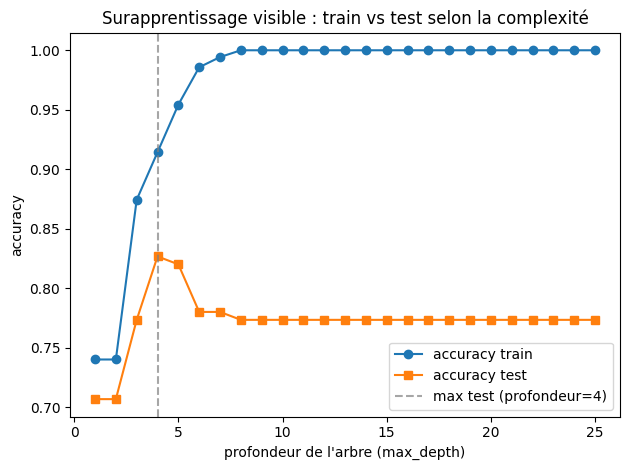

profondeur        4.000000
accuracy_train    0.914286
accuracy_test     0.826667
Name: 3, dtype: float64


In [6]:
# Exemple résolu : balayage de complexité (max_depth de 1 à 25)
depths = list(range(1, 26))
trains = []
tests = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    trains.append(accuracy_score(y_train, clf.predict(X_train)))
    tests.append(accuracy_score(y_test, clf.predict(X_test)))

sweep = pd.DataFrame({
    'profondeur': depths,
    'accuracy_train': trains,
    'accuracy_test': tests,
})

plt.figure()
plt.plot(sweep['profondeur'], sweep['accuracy_train'], marker='o', label='accuracy train')
plt.plot(sweep['profondeur'], sweep['accuracy_test'], marker='s', label='accuracy test')
# Marquer la profondeur d'accuracy test maximale
meilleur = sweep.loc[sweep['accuracy_test'].idxmax(), 'profondeur']
plt.axvline(meilleur, color='gray', linestyle='--', alpha=0.7, label=f'max test (profondeur={meilleur})')
plt.xlabel("profondeur de l'arbre (max_depth)")
plt.ylabel('accuracy')
plt.title("Surapprentissage visible : train vs test selon la complexité")
plt.legend()
plt.tight_layout()
plt.show()

# Ligne d'accuracy test maximale
print(sweep.loc[sweep['accuracy_test'].idxmax()])

### Exercice 2 : trouver la profondeur optimale

**Objectif.** À partir du DataFrame `sweep` construit ci-dessus, extrayez la **profondeur optimale** : celle qui maximise l'accuracy de test. Reportez ensuite l'accuracy d'entraînement et de test à cette profondeur.

**Indices.**

- *Indice* : `sweep['accuracy_test'].idxmax()` donne l'indice de la ligne où l'accuracy de test est maximale.
- *Étape 1* : calculer `indice_optimal = sweep['accuracy_test'].idxmax()`.
- *Étape 2* : récupérer `sweep.loc[indice_optimal, 'profondeur']`, `sweep.loc[indice_optimal, 'accuracy_train']` et `sweep.loc[indice_optimal, 'accuracy_test']`.

In [7]:
# Exercice 2 : profondeur optimale = argmax de l'accuracy test
# TODO etudiant : trouver l'indice de profondeur optimale puis la valeur
indice_optimal = None  # TODO etudiant : remplacer (idx de l'accuracy test maximale)
profondeur_optimale = None  # TODO etudiant : remplacer (sweep.loc[indice_optimal, 'profondeur'])
acc_train_opt = None  # TODO etudiant : remplacer
acc_test_opt = None  # TODO etudiant : remplacer
print(f"Exercice 2 a completer : profondeur optimale = {profondeur_optimale}, "
      f"train = {acc_train_opt}, test = {acc_test_opt}")

Exercice 2 a completer : profondeur optimale = None, train = None, test = None


## 6. Côté régression : une autre famille de métriques

Jusqu'ici nous faisions de la **classification** (étiquettes discrètes 0/1), mesurée par l'**accuracy** (proportion de prédictions correctes). En **régression**, la cible est un nombre **continu** : prédire « 2.51 » quand la vérité est « 2.49 » n'est ni totalement faux ni totalement juste. Il faut donc une métrique de **distance** entre prédiction et réalité.

La **MAE** (*mean absolute error*) est la moyenne des valeurs absolues des écarts :

$$ \mathrm{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

Plus la MAE est faible, meilleure est la régression (elle s'exprime dans la même unité que la cible).

> **Référence.** La MAE (mean absolute error) est l'un des estimateurs d'erreur les plus robustes pour la régression ; voir Hastie, Tibshirani & Friedman (2009), *The Elements of Statistical Learning*, Springer (2e éd.), section 11.6 pour la comparaison des critères de perte (L1 vs L2).

In [8]:
# Exemple résolu : régression linéaire et MAE
Xr, yr = make_regression(n_samples=300, n_features=5, noise=15.0, random_state=42)

# En régression, pas de stratify (la cible est continue)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=42)

modele_reg = LinearRegression()
modele_reg.fit(Xr_train, yr_train)
yr_pred = modele_reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
print("MAE (mean absolute error) : {:.3f}".format(mae))

MAE (mean absolute error) : 11.105


### Exercice 3 : recalculer la MAE à la main

**Objectif.** Recalculez la MAE **manuellement** avec NumPy (moyenne des valeurs absolues des résidus) et comparez-la à la valeur renvoyée par `mean_absolute_error` de scikit-learn. Elles doivent être égales.

**Indices.**

- *Indice* : `np.mean(np.abs(yr_pred - yr_test))`.
- *Étape 1* : calculer les résidus `yr_pred - yr_test`.
- *Étape 2* : prendre la valeur absolue puis la moyenne avec NumPy.

In [9]:
# Exercice 3 : MAE manuelle (moyenne des valeurs absolues des résidus)
# TODO etudiant : calculer la MAE à la main avec numpy
mae_manuelle = None  # TODO etudiant : remplacer
print(f"Exercice 3 a completer : MAE manuelle = {mae_manuelle}")

Exercice 3 a completer : MAE manuelle = None


## 7. Bonne pratique : le Pipeline

Le prétraitement (mise à l'échelle, imputation des valeurs manquantes…) doit **toujours** vivre à l'intérieur d'un `Pipeline` scikit-learn. Pourquoi ? Pour éviter les **fuites de données** (*data leakage*) : si l'on calcule les paramètres d'un `StandardScaler` (moyenne, écart-type) sur **tout** le jeu de données — test compris — puis qu'on évalue sur le test, le modèle a indirectement « vu » des informations issues du test. Le `Pipeline` garantit que le scaler est ajusté **uniquement** sur le fragment d'entraînement, puis appliqué au test sans réutiliser ses propres statistiques.

In [10]:
# Exemple résolu : un Pipeline (scaler + arbre) sans fuite de données
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(max_depth=4, random_state=42)),
])

# Même workflow que sans pipeline, mais le scaler ne voit que le train
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
acc_pipe = accuracy_score(y_test, y_pred_pipe)

print("Accuracy (Pipeline scaler + arbre) : {:.3f}".format(acc_pipe))
print("-> Le Pipeline applique le StandardScaler ajusté sur le train seulement :")
print("   aucune statistique du test ne fuite dans l'entraînement.")

Accuracy (Pipeline scaler + arbre) : 0.827
-> Le Pipeline applique le StandardScaler ajusté sur le train seulement :
   aucune statistique du test ne fuite dans l'entraînement.


## Conclusion et transition

**Récapitulatif.**

- Le **workflow** canonique : `train_test_split` → `fit` → `predict` → `evaluate`.
- On **sépare** train et test pour estimer honnêtement la **généralisation**.
- Le **surapprentissage** devient *visible* quand on balaye la complexité : l'écart train/test s'élargit.
- Le **choix de la métrique** dépend de la tâche : `accuracy` pour la classification, `MAE` pour la régression.
- Le **Pipeline** protège contre les fuites de données.

**Transition.** Le prochain notebook (`2.2-Descente-de-gradient`) ouvre la boîte noire : au lieu d'appeler `fit()`, nous implémenterons nous-mêmes l'optimisation qui fait apprendre un modèle.

## References

1. Mitchell, T. (1997). *Machine Learning*. McGraw-Hill. — Le surapprentissage et la distinction entraînement/généralisation comme concept central de l'apprentissage supervisé.
2. Stone, M. (1974). *Cross-Validatory Choice and Assessment of Statistical Predictions*. Journal of the Royal Statistical Society. Series B (Methodological) 36(2):111-147. — Le principe d'évaluation sur des données non vues.
3. Breiman, L., Friedman, J., Olshen, R. & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth. — Les arbres CART et la profondeur comme contrôle de complexité.
4. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.). — Compromis biais-variance, surapprentissage, critères de perte pour la régression.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — La bibliothèque scikit-learn utilisée dans tout ce notebook (`train_test_split`, `DecisionTreeClassifier`, `LinearRegression`, métriques, `Pipeline`).